# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, your goal is to compare the performance of the classifiers we encountered in this section, namely K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines.  We will utilize a dataset related to marketing bank products over the telephone.  



### Getting Started

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/ml/datasets/bank+marketing).  The data is from a Portugese banking institution and is a collection of the results of multiple marketing campaigns.  We will make use of the article accompanying the dataset [here](CRISP-DM-BANK.pdf) for more information on the data and features.



### Problem 1: Understanding the Data

To gain a better understanding of the data, please read the information provided in the UCI link above, and examine the **Materials and Methods** section of the paper.  How many marketing campaigns does this data represent?

According to the Materials and Methods section of the paper, the data represents 17 marketing campaigns.

### Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker


from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    ConfusionMatrixDisplay, RocCurveDisplay, classification_report
)

RANDOM_STATE=42


In [7]:
bank_data_full= pd.read_csv('data/bank-additional-full.csv', sep = ';')
bank_data = pd.read_csv('data/bank-additional.csv', sep=';')

In [8]:
bank_data_full.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [11]:
bank_data.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no


In [28]:
bank_data_full.shape, bank_data.shape
bank_data_full.duplicated().sum()

12

** Observations **

'bank-additional' is a smaller subset of 4119 observations, compared to 'bank-additional-full' with 41188.

In [14]:
def data_quality_report(df):
  return pd.DataFrame({
    'data_type': df.dtypes,
    'non_null_count': df.notnull().sum(),
    'null_count': df.isnull().sum(),
    'na_count': df.isna().sum(),
    'na_percentage': (df.isna().sum() / len(df)) * 100,
    'null_percentage': (df.isnull().sum() / len(df)) * 100,
    'unique_values': df.nunique(),
    'sample_value': df.sample().iloc[0]
  })

### Problem 3: Understanding the Features


Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.


```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
# other attributes:
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```



In [15]:
data_quality_report(bank_data_full)

,data_type,non_null_count,null_count,na_count,na_percentage,null_percentage,unique_values,sample_value
age,int64,41188,0,0,0.0,0.0,78,70
job,object,41188,0,0,0.0,0.0,12,retired
marital,object,41188,0,0,0.0,0.0,4,divorced
education,object,41188,0,0,0.0,0.0,8,basic.4y
default,object,41188,0,0,0.0,0.0,3,no
housing,object,41188,0,0,0.0,0.0,3,no
loan,object,41188,0,0,0.0,0.0,3,no
contact,object,41188,0,0,0.0,0.0,2,cellular
month,object,41188,0,0,0.0,0.0,10,jul
day_of_week,object,41188,0,0,0.0,0.0,5,thu


In [83]:
for col in bank_data_full.select_dtypes(include='object').columns.tolist():
  print(f'Unique values for column {col} are {bank_data_full[col].unique()}')

len(bank_data_full[bank_data_full['pdays'] == 999])

Unique values for column job are ['housemaid' 'services' 'admin.' 'blue-collar' 'technician' 'retired'
 'management' 'unemployed' 'self-employed' 'unknown' 'entrepreneur'
 'student']
Unique values for column marital are ['married' 'single' 'divorced' 'unknown']
Unique values for column education are ['basic.4y' 'high.school' 'basic.6y' 'basic.9y' 'professional.course'
 'unknown' 'university.degree' 'illiterate']
Unique values for column default are ['no' 'unknown' 'yes']
Unique values for column housing are ['no' 'yes' 'unknown']
Unique values for column loan are ['no' 'yes' 'unknown']
Unique values for column contact are ['telephone' 'cellular']
Unique values for column month are ['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'mar' 'apr' 'sep']
Unique values for column day_of_week are ['mon' 'tue' 'wed' 'thu' 'fri']
Unique values for column poutcome are ['nonexistent' 'failure' 'success']
Unique values for column y are ['no' 'yes']


39673

In [ ]:
bank_data_full['y'].value_counts()

y
no     36548
yes     4640
Name: count, dtype: int64

In [16]:
unknown_rate = (bank_data_full == 'unknown').mean().sort_values(ascending=False)
unknown_rate.head(15)

default           0.208726
education         0.042027
housing           0.024036
loan              0.024036
job               0.008012
marital           0.001942
age               0.000000
poutcome          0.000000
nr.employed       0.000000
euribor3m         0.000000
cons.conf.idx     0.000000
cons.price.idx    0.000000
emp.var.rate      0.000000
duration          0.000000
previous          0.000000
dtype: float64

In [29]:
bank_data_full[bank_data_full['poutcome'] == 'nonexistent']['poutcome'].count()

35563

In [31]:
unknown_counts = (bank_data_full == 'unknown').mean().sort_values(ascending=False)
display(unknown_rate.head(10))
nonexistent_rate = (bank_data_full == 'nonexistent').mean().sort_values(ascending=False)
display(nonexistent_rate)

default        0.208726
education      0.042027
housing        0.024036
loan           0.024036
job            0.008012
marital        0.001942
age            0.000000
poutcome       0.000000
nr.employed    0.000000
euribor3m      0.000000
dtype: float64

poutcome          0.863431
age               0.000000
campaign          0.000000
nr.employed       0.000000
euribor3m         0.000000
cons.conf.idx     0.000000
cons.price.idx    0.000000
emp.var.rate      0.000000
previous          0.000000
pdays             0.000000
duration          0.000000
job               0.000000
day_of_week       0.000000
month             0.000000
contact           0.000000
loan              0.000000
housing           0.000000
default           0.000000
education         0.000000
marital           0.000000
y                 0.000000
dtype: float64

In [25]:
print(f'Count of duplicate rows: {bank_data_full.duplicated().sum()}')

Count of duplicate rows: 12


#### Observations

During exploratory data analysis (EDA), we quantified missingness via computatin of proportion of default and nonexistent values in each columns. This allows us to answer the following question.

#### How much data is missing?

Is missingness widespread or concentrated in a few variables?

In this dataset, ~21% of default column values are unknown, while the remaining object column percentages range between 0-4% percent. As 86% of previous outcome columns are 'nonexistent', likely not a column to consider for valid use 

### Target distribution
per this bank dataset, the subscription rate is inspected to choose appropriate evaluation metrics.

In [34]:
y_counts = bank_data_full['y'].value_counts(dropna=False)
display(y_counts)

display((y_counts / len(bank_data_full)).rename('proportion'))

y
no     36548
yes     4640
Name: count, dtype: int64

y
no     0.887346
yes    0.112654
Name: proportion, dtype: float64

In [35]:
y_counts = bank_data['y'].value_counts(dropna=False)
display(y_counts)

display((y_counts / len(bank_data)).rename('proportion'))

y
no     3668
yes     451
Name: count, dtype: int64

y
no     0.890507
yes    0.109493
Name: proportion, dtype: float64

4131

### Problem 4: Understanding the Task

After examining the description and data, your goal now is to clearly state the *Business Objective* of the task.  State the objective below.

**Business objective:** predict the likelihood of customers to subscribe to a term deposit following a marketing campaign, enabling the bank to:
- *optimize contract strategy* via prioritization of high-probability prospects
- *reduce campaign costs* by minimizing outreach to unlikely converters
- *improve conversion rates* through targeted, data-driven customer selection

**ML Objective:** learn predictive mapping from client demographic features, interaction history, and macroeconomic indicators to a binary subscription outcome (yes/no), then:
- **Train multiple classification models** (e.g. logistic regression, knearest neighbors, decision trees)
- **Evaluate model performance** using cross-validation on training data and final assessment on held-out test set
- **Optimize for business-relevant metics** such as precision, recall 

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

In [57]:
object_cols = bank_data_full.select_dtypes(include=['object']).columns.tolist()

bank_data_clean = bank_data_full[~(bank_data_full[object_cols] == 'unknown').any(axis=1)]
bank_data_clean.drop(columns=['poutcome'], inplace=True)

bank_data_clean.shape, bank_data_full.shape

/var/folders/zq/7j33ffkd46vd0yzyrk5qyj140000gn/T/ipykernel_4412/624147633.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bank_data_clean.drop(columns=['poutcome'], inplace=True)


((30488, 20), (41188, 21))

In [ ]:
X = bank_data_full.drop(columns=['y']).copy()
y = (bank_data_full['y'] == 'yes').astype(int)

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X.columns if c not in num_cols]

print("Numeric features:", len(num_cols))
print("Categorical features:", len(cat_cols))
print("Target classes:", pd.Series(y).value_counts().to_dict())

Numeric features: 10
Categorical features: 10
Target classes: {0: 36548, 1: 4640}


In [74]:
numeric_transformer = Pipeline([
  ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
  ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

preprocessor = ColumnTransformer(
  transformers=[
    ('num', numeric_transformer, num_cols),
    ('cat', categorical_transformer, cat_cols)
  ],
  remainder='drop'
)

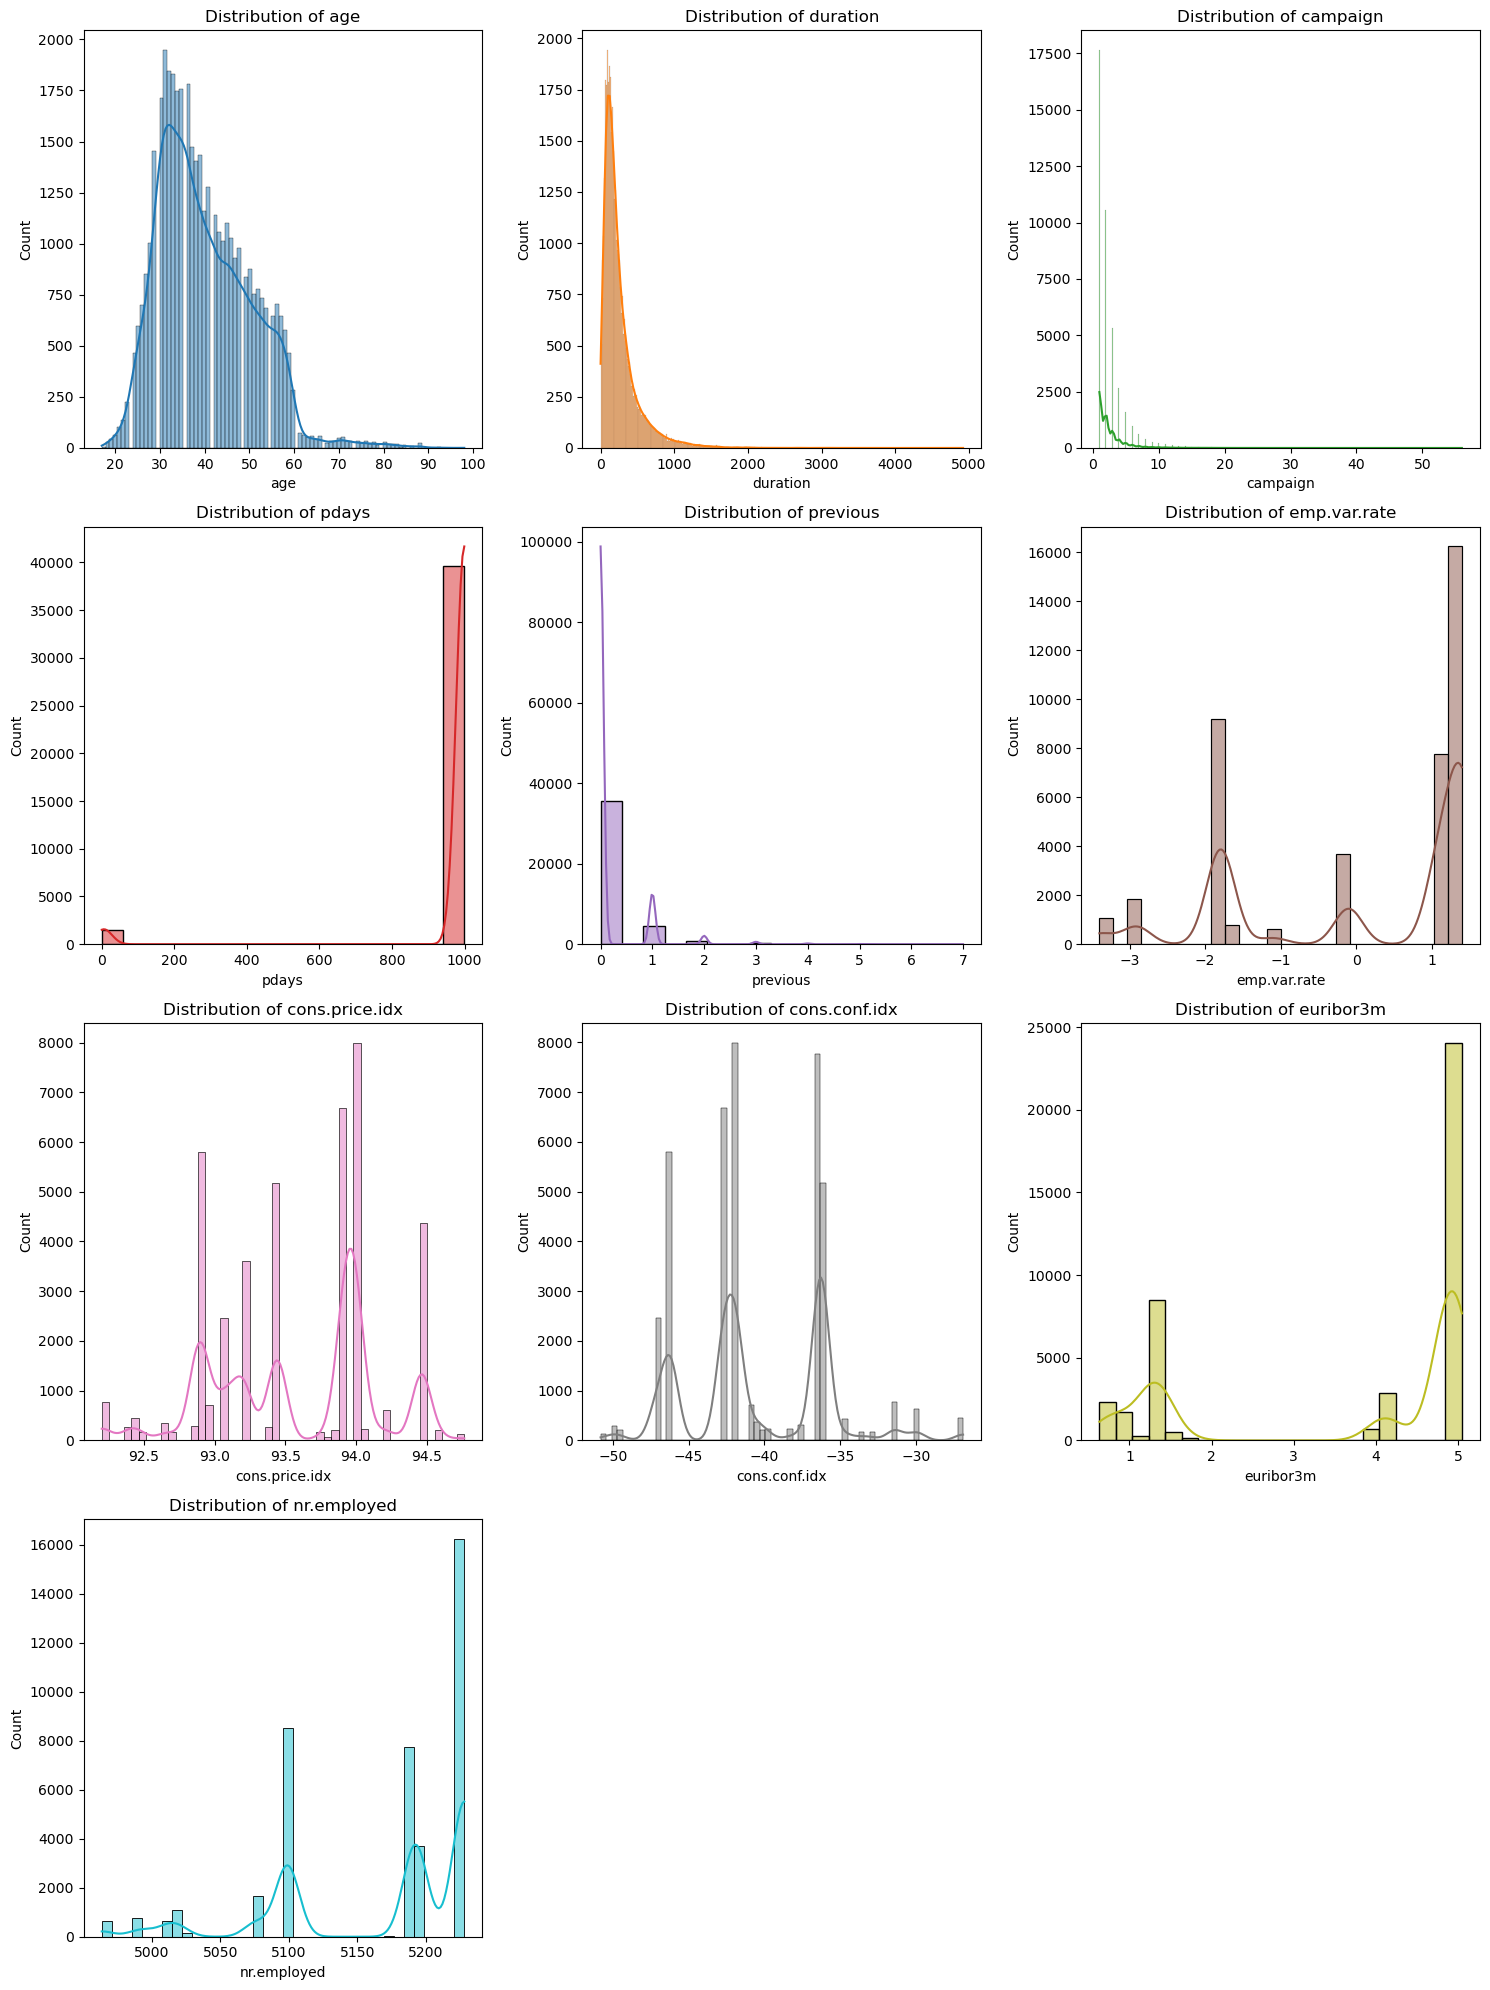

In [65]:
num_to_plot = [c for c in num_cols if bank_data_full[c].nunique() > 5]

# Calculate rows and columns for better layout
n_plots = len(num_to_plot)
n_cols = 3  # 3 plots per row (adjust as needed)
n_rows = (n_plots + n_cols - 1) // n_cols  # Ceiling division

# Create subplots with proper dimensions
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))

# Flatten axes array for easy iteration
axes = axes.flatten() if n_plots > 1 else [axes]

# Plot each distribution
for idx, col in enumerate(num_to_plot):
    sns.histplot(data=bank_data_full, x=col, kde=True, ax=axes[idx], color=f'C{idx}')
    axes[idx].set_title(f"Distribution of {col}")
    axes[idx].set_xlabel(col)

# Hide unused subplots
for idx in range(n_plots, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

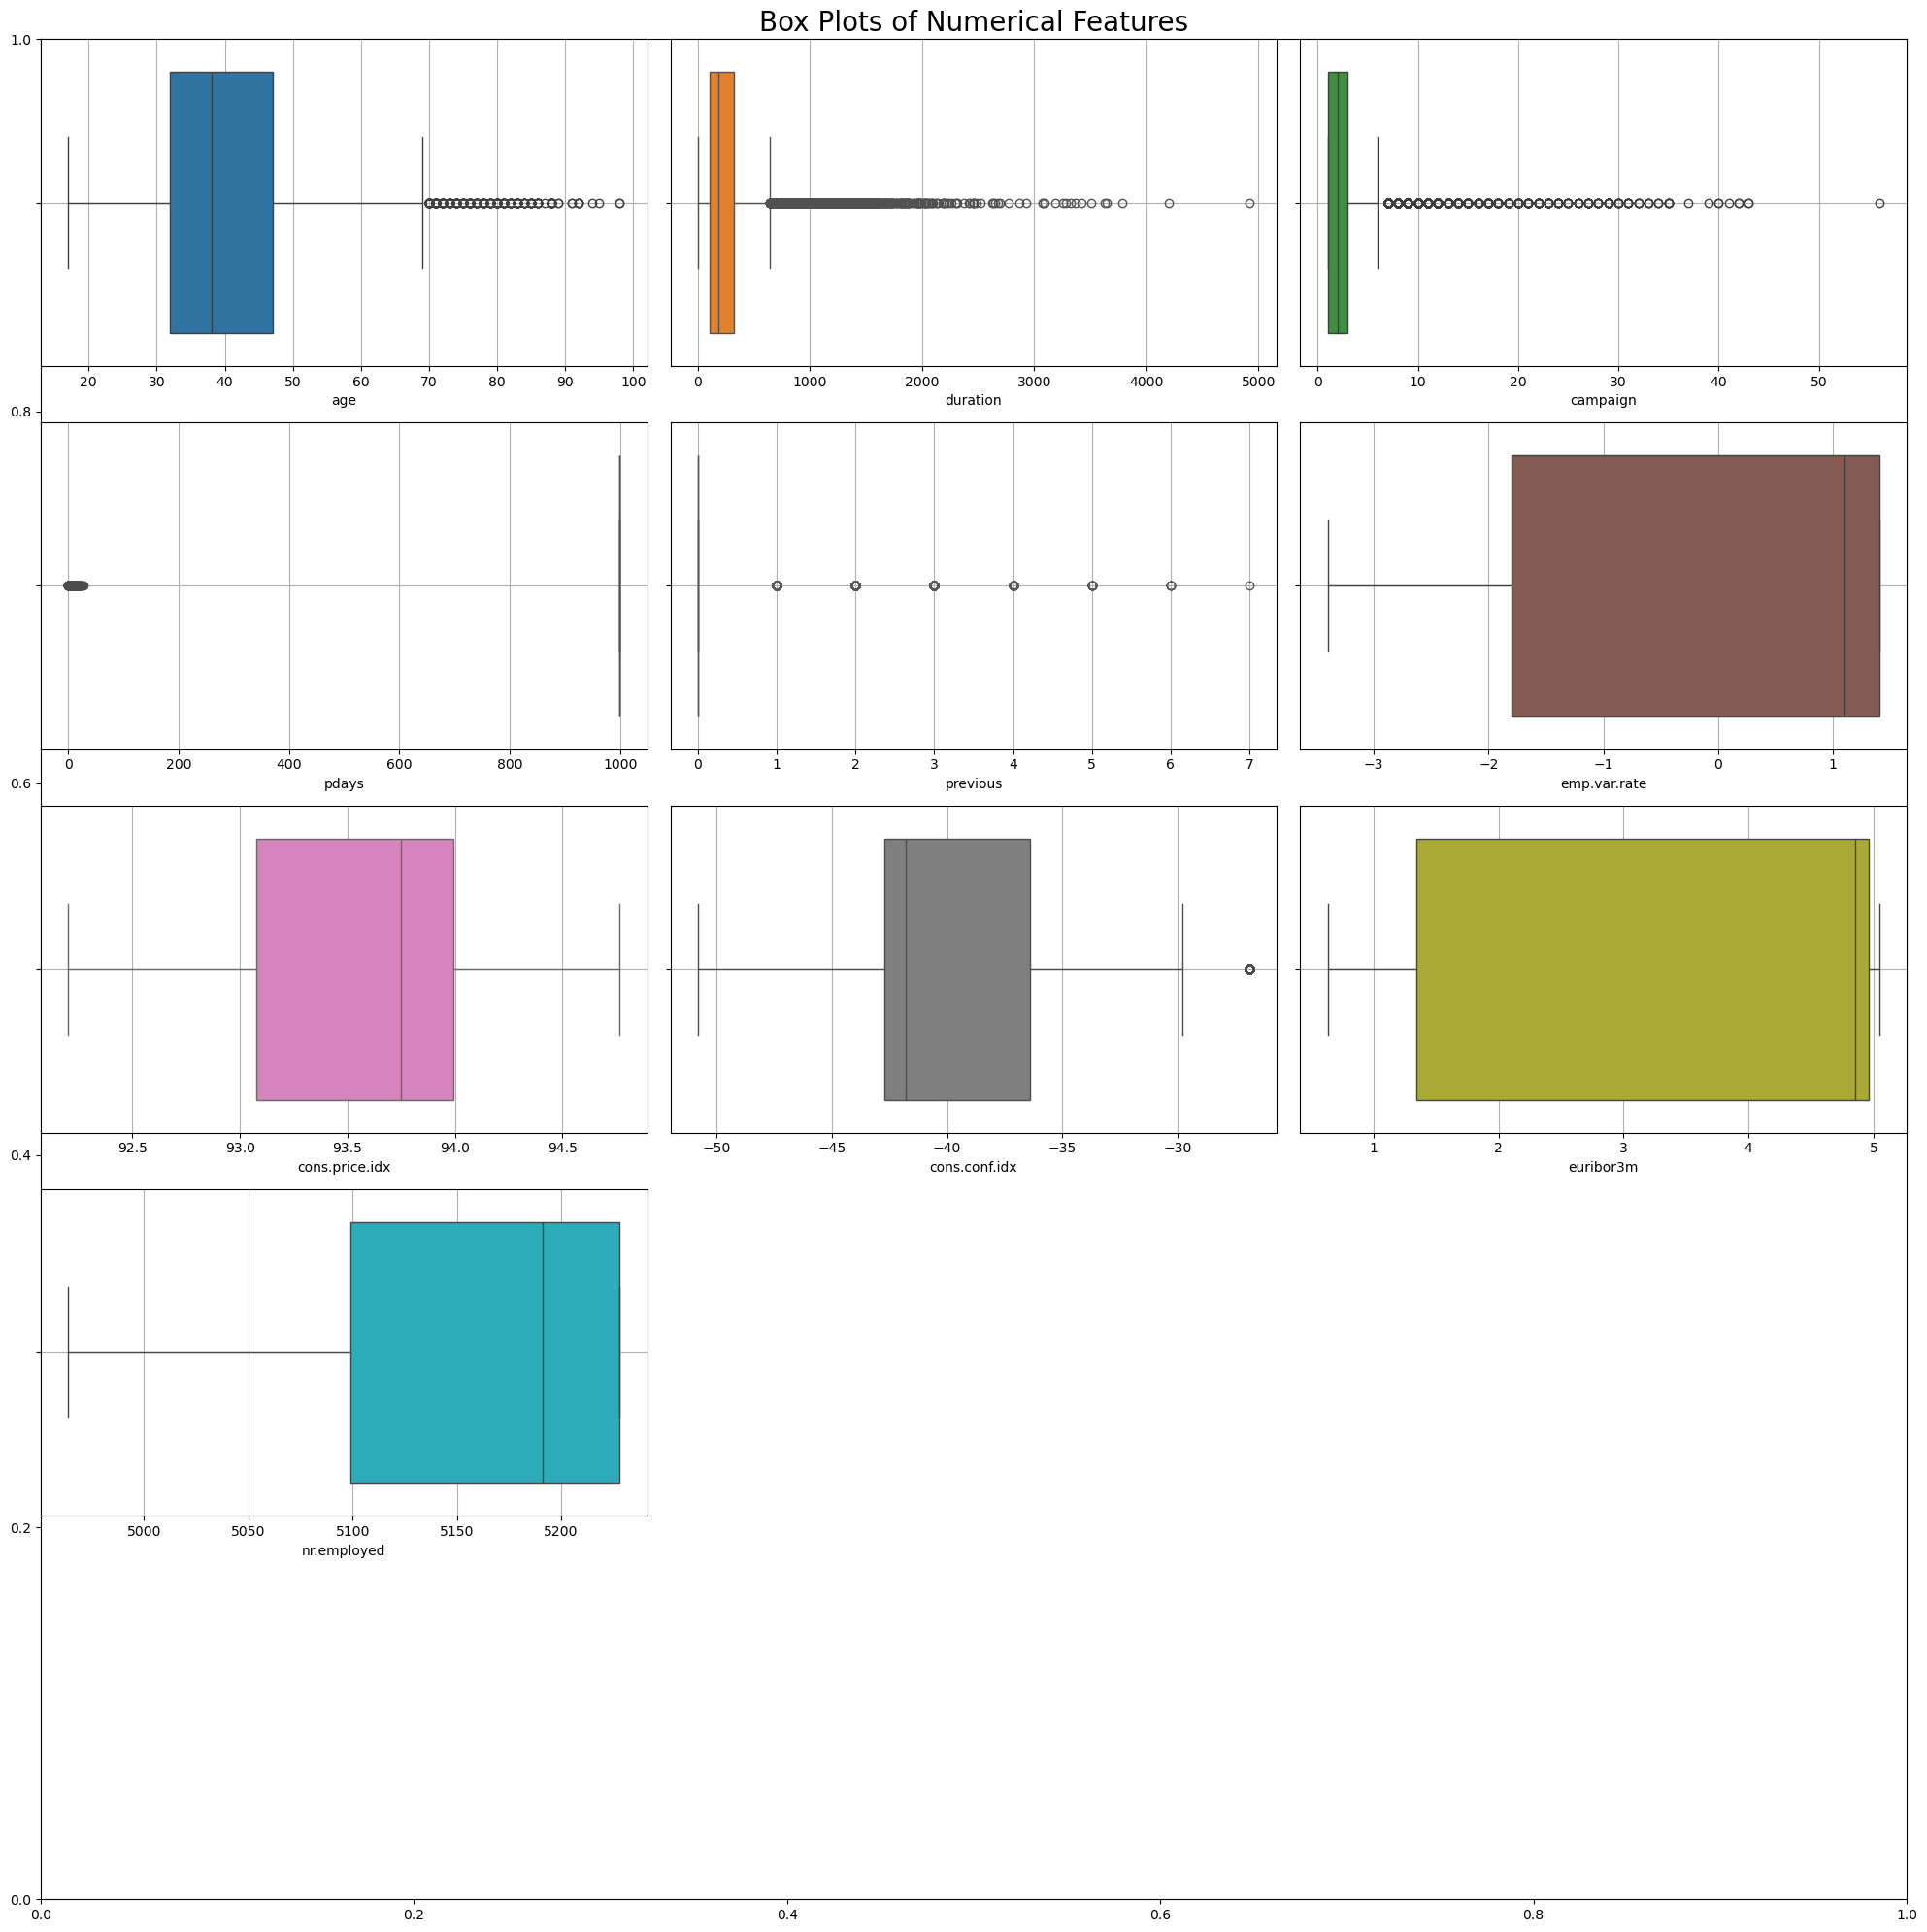

In [ ]:

# Create scatter plots
num_plots = len(num_cols)
rows = (num_plots // 3) + 1  # Arrange plots in rows of 3
plt.figure(figsize=(20, 20))  # Adjust overall figure size
plt.suptitle("Box Plots of Numerical Features", fontsize=20, y=1.0)

for i, col in enumerate(num_cols):
    plt.subplot(5, 3, i + 1)
    sns.boxplot(x=bank_data_full[col], color=f'C{i}')
    plt.grid(True, which='both')
        
plt.tight_layout()
plt.savefig('images/numerical-box-plots.png')
plt.show()

In [ ]:


bank_data_full[num_cols + [y]].corr()

AttributeError: 'list' object has no attribute 'concat'

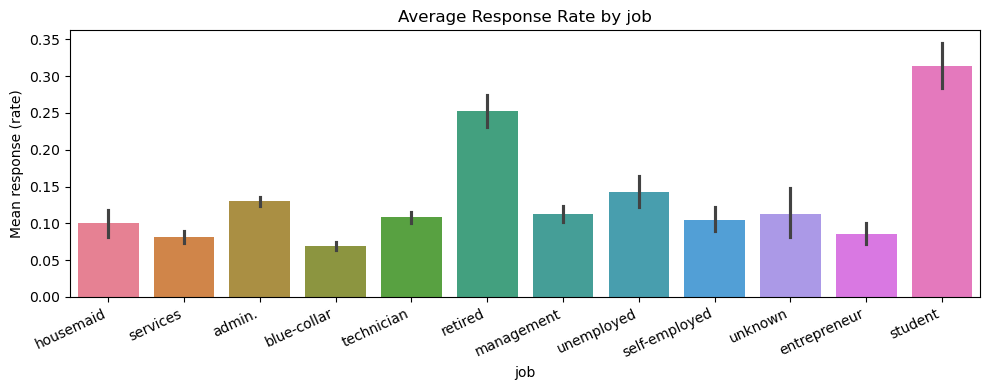

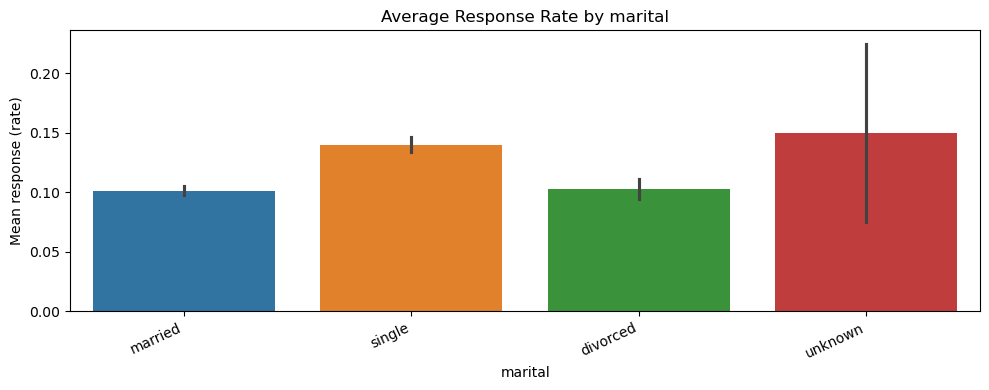

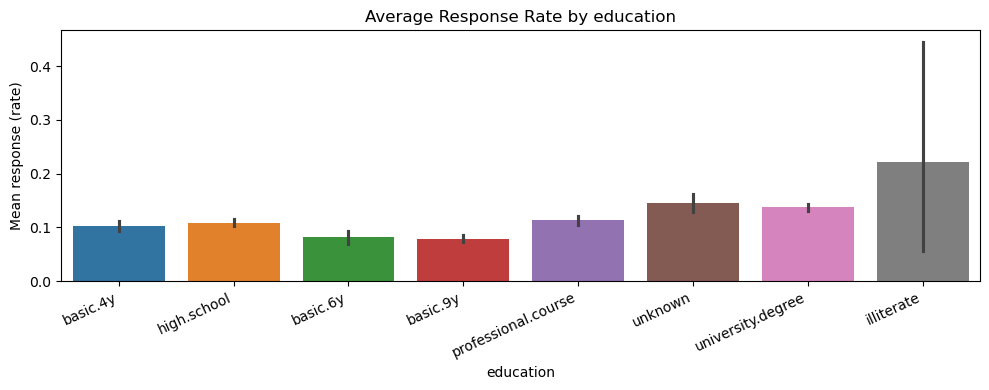

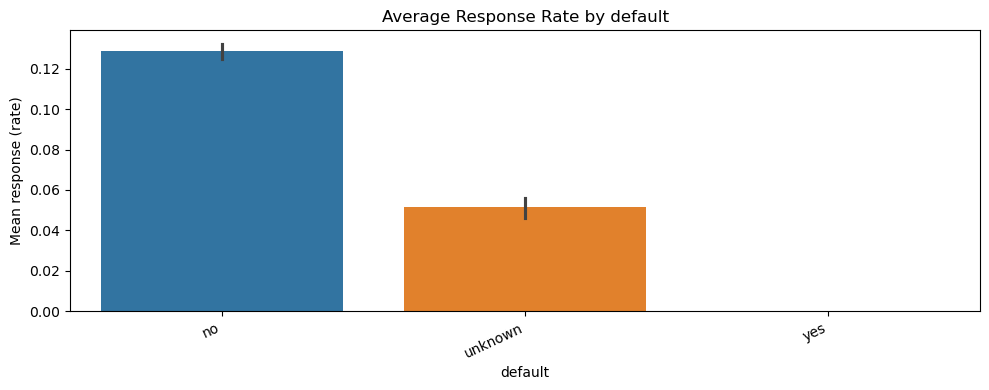

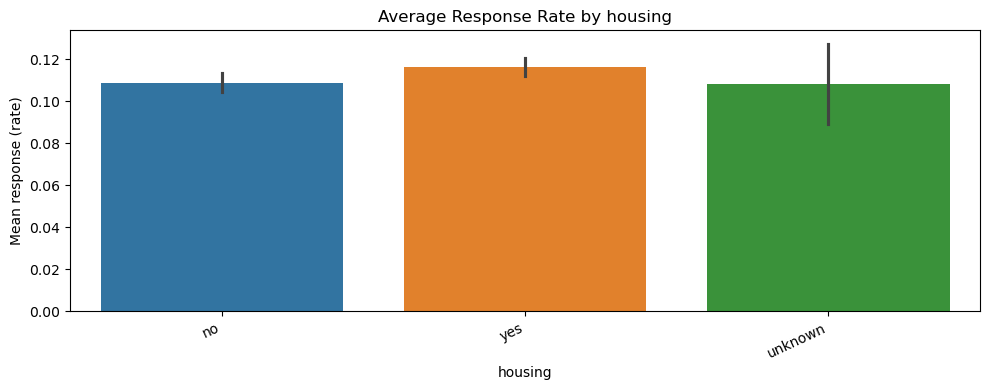

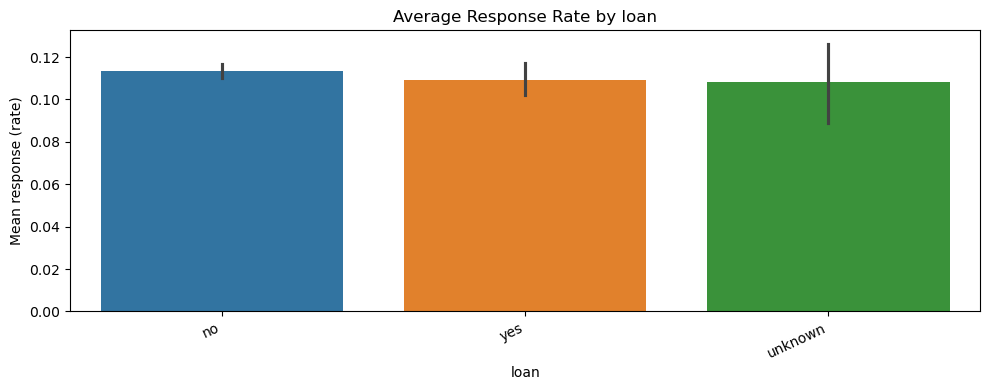

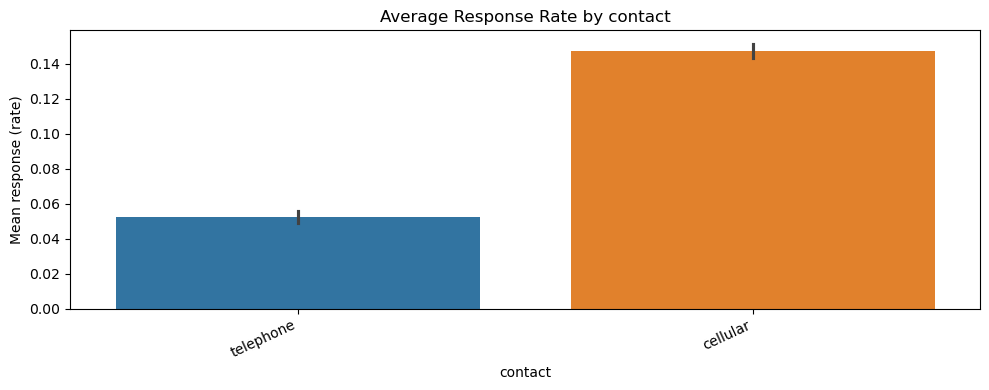

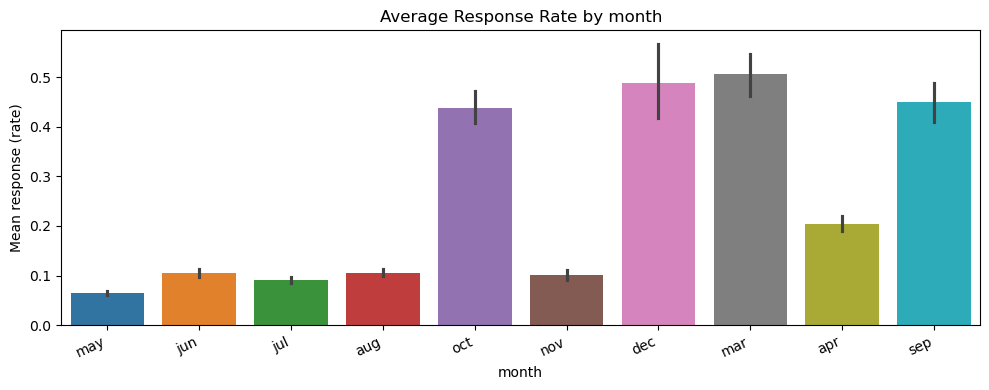

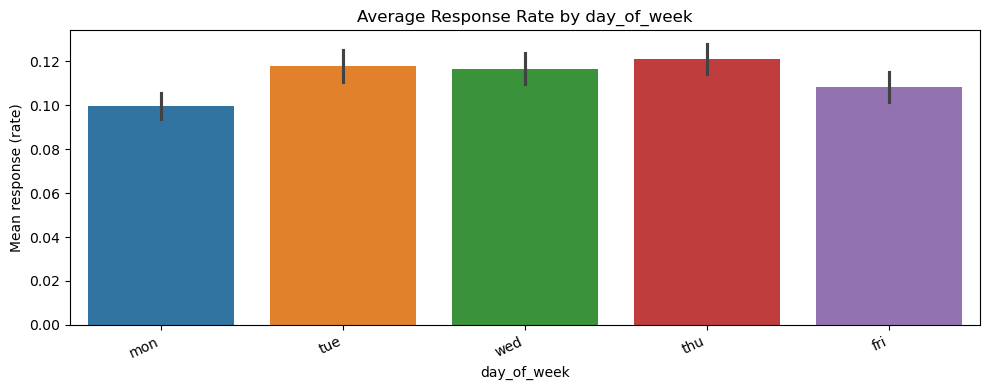

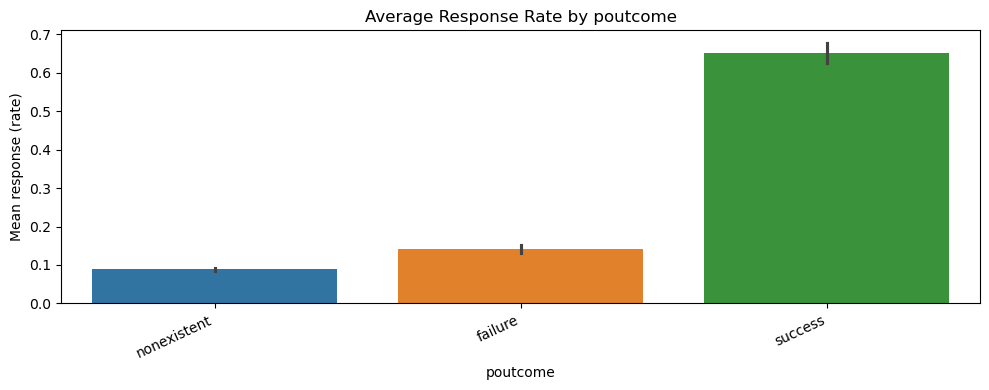

In [71]:
cat_to_plot = cat_cols[:10]
for idx, col in enumerate(cat_to_plot):
    plt.figure(figsize=(10, 4))
    tmp = pd.DataFrame({col: X[col], "Response": y})
    # Use palette for different colors per bar
    sns.barplot(data=tmp, x=col, y="Response", hue=col)
    
    plt.title(f"Average Response Rate by {col}")
    plt.xticks(rotation=25, ha="right")
    plt.xlabel(col)
    plt.ylabel("Mean response (rate)")
    plt.tight_layout()
    plt.show()

### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

In [75]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y if pd.Series(y).nunique() > 1 else None
)

print("Train size:", X_train.shape, "Test size:", X_test.shape)

Train size: (32950, 20) Test size: (8238, 20)


### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

In [76]:
baseline_lr = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=2000, random_state=42))
])

baseline_lr.fit(X_train, y_train)
baseline_pred = baseline_lr.predict(X_test)
baseline_proba = baseline_lr.predict_proba(X_test)[:, 1]

print("Baseline Logistic Regression (test):")
print("Accuracy:", accuracy_score(y_test, baseline_pred))
print("F1:", f1_score(y_test, baseline_pred, zero_division=0))
print("ROC-AUC:", roc_auc_score(y_test, baseline_proba))

Baseline Logistic Regression (test):
Accuracy: 0.9162418062636563
F1: 0.5387700534759359
ROC-AUC: 0.942476355016746


### Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.  

In [77]:

knn_pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", KNeighborsClassifier(n_neighbors=15))
])

knn_pipe.fit(X_train, y_train)
knn_pred = knn_pipe.predict(X_test)
knn_proba = knn_pipe.predict_proba(X_test)[:, 1]

print("KNN (test):")
print("Accuracy:", accuracy_score(y_test, knn_pred))
print("F1:", f1_score(y_test, knn_pred, zero_division=0))
print("ROC-AUC:", roc_auc_score(y_test, knn_proba))

KNN (test):
Accuracy: 0.907623209516873
F1: 0.4889187374076561
ROC-AUC: 0.9232024505872918


In [79]:
k_used = knn_pipe.named_steps['model'].n_neighbors
print(f"K used in KNN: {k_used}")

K used in KNN: 15


### Problem 9: Score the Model

What is the accuracy of your model?

### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each.  Also, be sure to compare the fit time of each of the models.  Present your findings in a `DataFrame` similar to that below:

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------  | -----------   |
|     |    |.     |.     |

In [81]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

models = {
    "KNN": KNeighborsClassifier(),
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "SVM (RBF)": SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE)
}

cv_rows = []
for name, model in models.items():
    pipe = Pipeline(steps=[("preprocess", preprocessor), ("model", model)])
    out = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    cv_rows.append({
        "model": name,
        "accuracy": out["test_accuracy"].mean(),
        "precision": out["test_precision"].mean(),
        "recall": out["test_recall"].mean(),
        "f1": out["test_f1"].mean(),
        "roc_auc": out["test_roc_auc"].mean()
    })

holdout_df = pd.DataFrame(cv_rows).sort_values("f1", ascending=False).reset_index(drop=True)
holdout_df

,model,accuracy,precision,recall,f1,roc_auc
0,Decision Tree,0.888680,0.505988,0.518047,0.511909,0.726891
1,Logistic Regression,0.909347,0.655086,0.413255,0.506724,0.933079
2,SVM (RBF),0.909560,0.668116,0.393316,0.494944,0.902686
3,KNN,0.900000,0.577576,0.421336,0.486969,0.864498


### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these.  Below, we list a few things to explore in this pursuit.


- Hyperparameter tuning and grid search.  All of our models have additional hyperparameters to tune and explore.  For example the number of neighbors in KNN or the maximum depth of a Decision Tree.  
- Adjust your performance metric

##### Questions